In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nih-chest-xrays/data")

print("Path to dataset files:", path)

100%|██████████| 42.0G/42.0G [07:56<00:00, 94.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3


### ① Data Understanding

First, we will examine the basic information of the dataset and the distribution of disease labels. This will allow us to understand any biases present in the data.

In [ ]:
import pandas as pd
import os
import kagglehub # Added this import to potentially re-define path

# Ensure 'path' is defined. It should have been defined in a previous cell (pANmKzAYfOnf).
# If the kernel state was reset, this block will re-download the dataset if necessary,
# ensuring 'path' is available for this cell.
if 'path' not in locals() and 'path' not in globals():
    print("Warning: 'path' variable not found in current session. Attempting to re-download dataset...")
    path = kagglehub.dataset_download("nih-chest-xrays/data")
    print("Dataset re-downloaded to:", path)

csv_path = os.path.join(path, 'Data_Entry_2017.csv')
df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (112120, 12)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


Next, we will analyze the `Finding Labels` column to check for any bias in the number of data points for each disease. This column may contain multiple labels separated by pipes `|`.

In [ ]:
# Calculate the count of each disease label
all_labels = []
for labels_str in df['Finding Labels']:
    labels = labels_str.split('|')
    all_labels.extend(labels)

label_counts = pd.Series(all_labels).value_counts()

print("Distribution of Finding Labels:")
display(label_counts)

# Also check the percentage
print("\nPercentage of Finding Labels:")
display(label_counts / len(all_labels) * 100)

print("The number of all diseases found in the images:")
display(len(all_labels))

# Especially check the percentage of 'No Finding'
if 'No Finding' in label_counts:
    no_finding_percentage = (label_counts['No Finding'] / df.shape[0]) * 100
    print(f"\n'No Finding' instances (unique images, not total labels): {df['Finding Labels'].str.contains('No Finding').sum()} ({no_finding_percentage:.2f}% of total images)")

Distribution of Finding Labels:


,count
No Finding,60361
Infiltration,19894
Effusion,13317
Atelectasis,11559
Nodule,6331
Mass,5782
Pneumothorax,5302
Consolidation,4667
Pleural_Thickening,3385
Cardiomegaly,2776



Percentage of Finding Labels:


,count
No Finding,42.646799
Infiltration,14.055689
Effusion,9.408847
Atelectasis,8.166769
Nodule,4.473035
Mass,4.085151
Pneumothorax,3.746017
Consolidation,3.297371
Pleural_Thickening,2.391601
Cardiomegaly,1.961325


The number of all diseases found in the images:


141537


'No Finding' instances (unique images, not total labels): 60361 (53.84% of total images)


### ② Data Splitting

A crucial rule for data splitting is to ensure that images from the same patient do not overlap across the training, validation, and test sets. To prevent this data leakage, we will split the dataset based on `Patient ID`.

Furthermore, considering the imbalance of disease labels and the characteristics of multi-label classification, we will apply stratified sampling. To avoid the problem of too many disease label combinations for stratification keys, we will simplify each patient's disease status into aggregated categories: "No Finding only," "1 type of disease," "2 types of diseases," or "3 or more types of diseases."

This will ensure that each dataset (training, validation, and test) is representative in terms of disease distribution.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# Get all unique disease labels (excluding 'No Finding')
all_disease_labels = sorted([label for label in label_counts.index if label != 'No Finding'])
print("All unique disease labels (excluding 'No Finding'):", all_disease_labels)

# --- Stratification Key Generation --- #

# Helper function to get a patient-level stratification key based on disease presence and count.
def get_patient_stratification_key(patient_df_group, all_disease_labels_list):
    all_finding_labels_for_patient = []
    for labels_str in patient_df_group['Finding Labels'].tolist():
        all_finding_labels_for_patient.extend(labels_str.split('|'))

    unique_diseases_for_patient = set()
    has_no_finding = False
    for label in all_finding_labels_for_patient:
        if label == 'No Finding':
            has_no_finding = True
        elif label in all_disease_labels_list:
            unique_diseases_for_patient.add(label)

    if not unique_diseases_for_patient and has_no_finding:
        # Patient has only 'No Finding' across all their images
        return "No_Finding_Only"
    elif unique_diseases_for_patient:
        # Patient has at least one disease. Stratify by number of unique diseases.
        num_diseases = len(unique_diseases_for_patient)
        if num_diseases == 1:
            return "Diseases_1"
        elif num_diseases == 2:
            return "Diseases_2"
        elif num_diseases >= 3: # Group 3 or more diseases together
            return "Diseases_3Plus"
        else: # Should not happen if unique_diseases_for_patient is not empty
            return "Unknown_Disease_Count"
    else:
        # Patient has neither 'No Finding' nor any specific disease (e.g., empty 'Finding Labels' string)
        # This is an edge case, but good to handle.
        return "No_Labels_Found"

# Generate a stratification key for each unique patient
# `patient_stratify_keys` will be a Series with Patient ID as index
# and a simplified stratification string as its value.
patient_stratify_keys = df.groupby('Patient ID').apply(
    lambda x: get_patient_stratification_key(x, all_disease_labels)
)

# Get the list of unique patient IDs that will be split
patient_ids_for_split = patient_stratify_keys.index.to_numpy()

# Create the `y` array for the `stratify` parameter, matching the order of `patient_ids_for_split`
# This `y` array contains the stratification key for each patient.
stratify_y = patient_stratify_keys.to_numpy()

print(f"Number of unique stratification key combinations: {len(np.unique(stratify_y))}")

# --- End of Stratification Key Generation --- #

# Split Patient IDs for training, validation, and testing
# First, split into training+validation and test sets (e.g., 80% / 20%)
# Stratified sampling is performed using patient-specific disease label information for the `stratify` parameter.
patient_train_val, patient_test, _, _ = train_test_split(
    patient_ids_for_split, stratify_y, test_size=0.2, random_state=42, stratify=stratify_y
)

# Next, split training+validation into training and validation sets (e.g., 70% training, 10% validation from 80% total)
val_size_relative_to_train_val = (0.1 / (1 - 0.2)) # 0.1 / 0.8 = 0.125

# The `stratify` argument passed to `train_test_split` must correspond to the data being split (`patient_train_val`).
# Therefore, filter and use stratification keys that match the patient IDs included in `patient_train_val`.
stratify_y_train_val = patient_stratify_keys.loc[patient_train_val].to_numpy()

patient_train, patient_val, _, _ = train_test_split(
    patient_train_val,
    stratify_y_train_val, # Use the filtered stratification keys
    test_size=val_size_relative_to_train_val,
    random_state=42,
    stratify=stratify_y_train_val # Use the filtered stratification keys
)

print(f"Total unique patients: {len(patient_ids_for_split)}")
print(f"Train patients: {len(patient_train)}")
print(f"Validation patients: {len(patient_val)}")
print(f"Test patients: {len(patient_test)}")

# Create dataframes based on the split patient IDs
df_train = df[df['Patient ID'].isin(patient_train)]
df_val = df[df['Patient ID'].isin(patient_val)]
df_test = df[df['Patient ID'].isin(patient_test)]

print(f"\nTrain dataset shape: {df_train.shape}")
print(f"Validation dataset shape: {df_val.shape}")
print(f"Test dataset shape: {df_test.shape}")

# Display a few sample images from each set
print("\nTrain set head:")
display(df_train.head())

All unique disease labels (excluding 'No Finding'): ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
Number of unique stratification key combinations: 4
Total unique patients: 30805
Train patients: 21563
Validation patients: 3081
Test patients: 6161

Train dataset shape: (78059, 12)
Validation dataset shape: (12007, 12)
Test dataset shape: (22054, 12)

Train set head:


/tmp/ipykernel_6617/3229201189.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  patient_stratify_keys = df.groupby('Patient ID').apply(


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


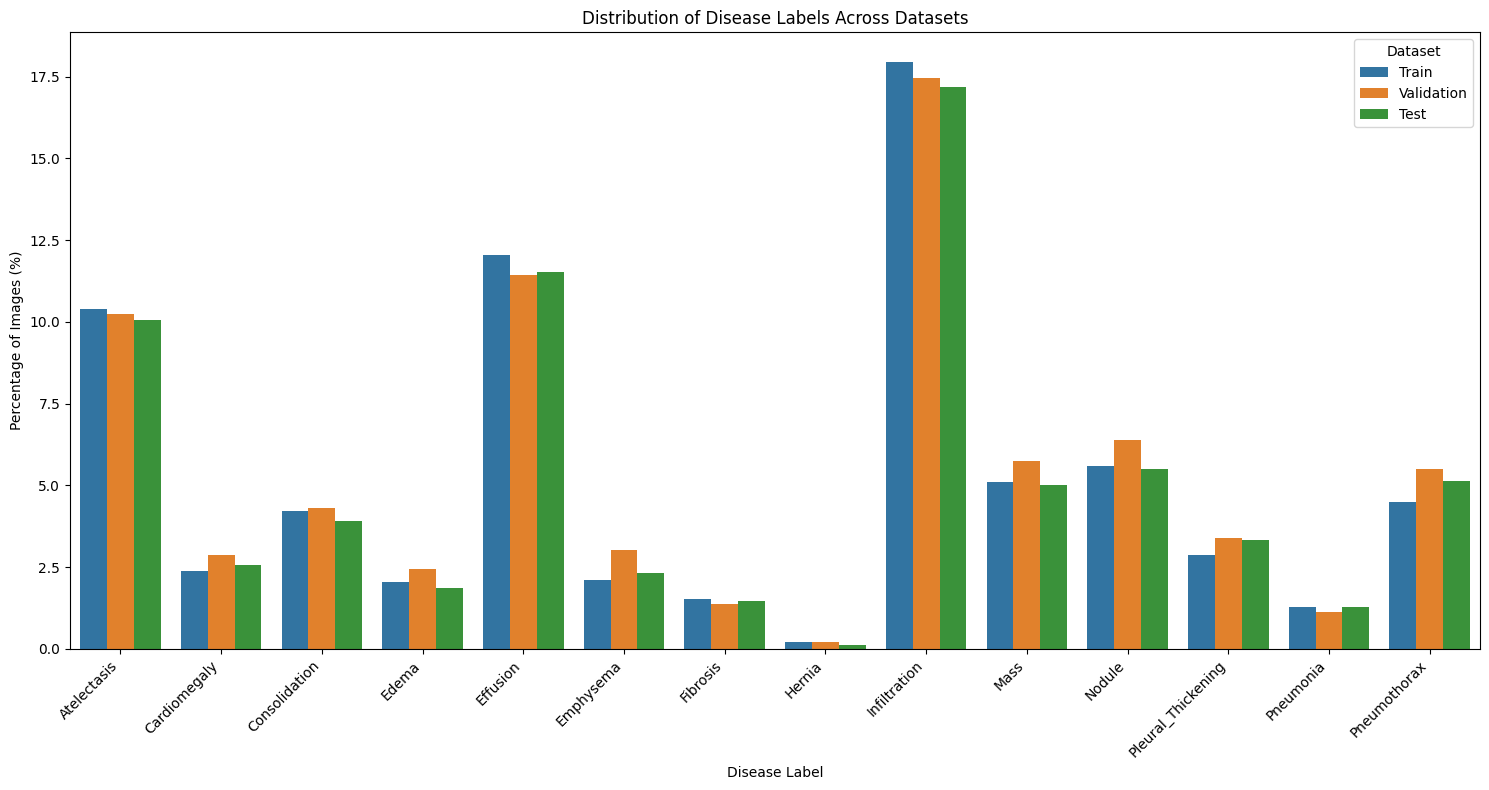

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Plot 1: Disease Label Distribution across Splits ---

def get_disease_distribution(df_subset, all_labels_list, dataset_name):
    subset_labels = []
    for labels_str in df_subset['Finding Labels']:
        labels = labels_str.split('|')
        subset_labels.extend([l for l in labels if l != 'No Finding'])

    # Count occurrences of each disease
    disease_counts = pd.Series(subset_labels).value_counts().reindex(all_labels_list, fill_value=0)

    # Normalize to get percentage of images in the subset that have this disease
    # We divide by the number of *images* in the subset, not the total number of labels,
    # to show prevalence within the dataset split.
    disease_percentages = (disease_counts / len(df_subset)) * 100

    return pd.DataFrame({
        'Disease': disease_percentages.index,
        'Percentage': disease_percentages.values,
        'Dataset': dataset_name
    })

# Get distributions for each split
dist_train = get_disease_distribution(df_train, all_disease_labels, 'Train')
dist_val = get_disease_distribution(df_val, all_disease_labels, 'Validation')
dist_test = get_disease_distribution(df_test, all_disease_labels, 'Test')

# Concatenate for plotting
combined_disease_dist = pd.concat([dist_train, dist_val, dist_test])

plt.figure(figsize=(15, 8))
sns.barplot(x='Disease', y='Percentage', hue='Dataset', data=combined_disease_dist)
plt.title('Distribution of Disease Labels Across Datasets')
plt.ylabel('Percentage of Images (%)')
plt.xlabel('Disease Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The chart above visualizes the distribution of each disease label (excluding 'No Finding') as a percentage of images within the training, validation, and test sets. This helps confirm that disease prevalence is maintained across the splits, which is crucial for fair model evaluation.

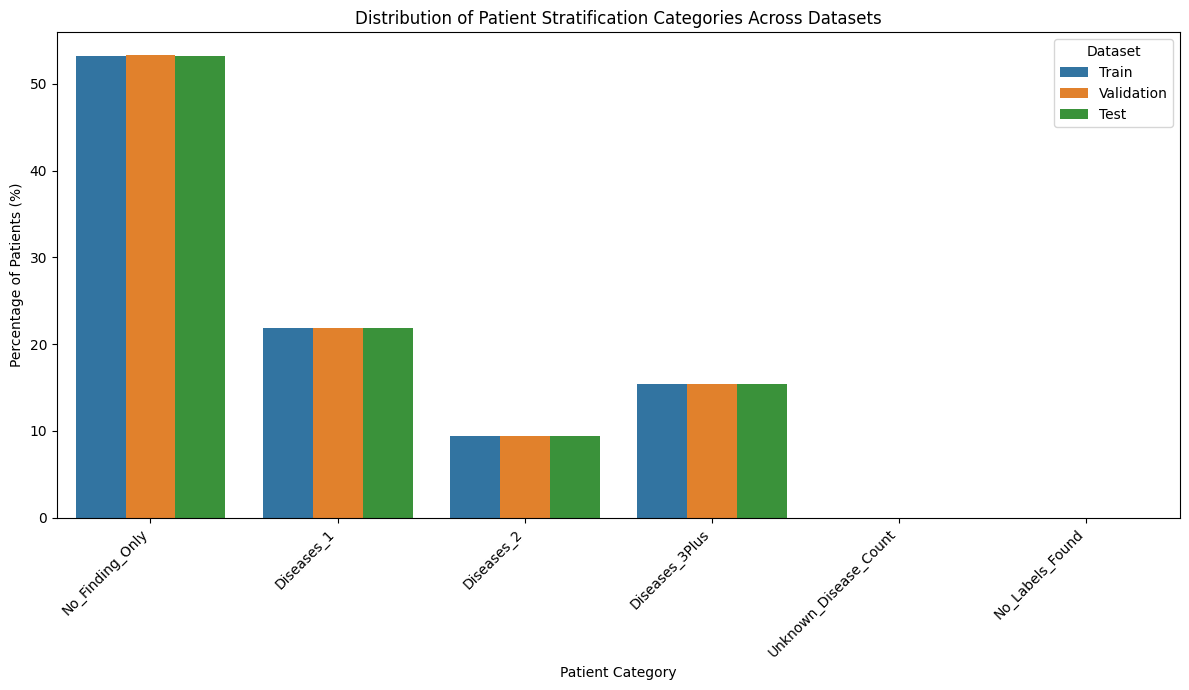

In [ ]:
# --- Plot 2: Patient Stratification Key Distribution across Splits ---

def get_strat_key_distribution(patient_ids_subset, patient_strat_keys_series, dataset_name):
    subset_strat_keys = patient_strat_keys_series.loc[patient_ids_subset]
    strat_key_counts = subset_strat_keys.value_counts(normalize=True) * 100

    # Ensure all possible keys are present for consistent plotting
    all_possible_keys = ['No_Finding_Only', 'Diseases_1', 'Diseases_2', 'Diseases_3Plus', 'Unknown_Disease_Count', 'No_Labels_Found']
    strat_key_counts = strat_key_counts.reindex(all_possible_keys, fill_value=0)

    return pd.DataFrame({
        'Category': strat_key_counts.index,
        'Percentage': strat_key_counts.values,
        'Dataset': dataset_name
    })

# Get distributions for each split
strat_dist_train = get_strat_key_distribution(patient_train, patient_stratify_keys, 'Train')
strat_dist_val = get_strat_key_distribution(patient_val, patient_stratify_keys, 'Validation')
strat_dist_test = get_strat_key_distribution(patient_test, patient_stratify_keys, 'Test')

# Concatenate for plotting
combined_strat_dist = pd.concat([strat_dist_train, strat_dist_val, strat_dist_test])

plt.figure(figsize=(12, 7))
sns.barplot(x='Category', y='Percentage', hue='Dataset', data=combined_strat_dist)
plt.title('Distribution of Patient Stratification Categories Across Datasets')
plt.ylabel('Percentage of Patients (%)')
plt.xlabel('Patient Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This second chart displays the distribution of the aggregated patient disease categories ('No_Finding_Only', 'Diseases_1', 'Diseases_2', 'Diseases_3Plus') across the train, validation, and test patient sets. This confirms that the stratified splitting mechanism successfully maintained the proportionality of these patient types in each subset, preventing data leakage and ensuring a robust evaluation.

In [ ]:
# Let's actually look at the first patient's group
first_patient_id = df['Patient ID'].unique()[0] # Get the first patient ID
example_group = df[df['Patient ID'] == first_patient_id] # Manually reproduce what groupby does in reality

print(f"--- Data for Patient ID: {first_patient_id} ---")
display(example_group)

--- Data for Patient ID: 1 ---


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN


### ③ Strategy for Pre-processing

This section describes the pre-processing strategy for images and labels. While the actual code implementation is often done as part of the model training pipeline, here we clarify the approach.

#### 1. Resizing

*   **Policy:** Original image size (1024x1024) will be reduced to 224x224, a size commonly used in Vision Transformers. This improves processing speed and reduces memory usage.

#### 2. Normalization

*   **Policy:** Image pixel values (0-255) will be normalized to the range of 0-1. Furthermore, standardizing the image data using ImageNet's mean and standard deviation will also be considered. This tends to stabilize model training.
    *   `pixel_value / 255.0`
    *   `(pixel_value - mean) / std_dev`

#### 3. RGB Conversion

*   **Policy:** X-ray images are typically grayscale, but many deep learning models (especially those pre-trained on ImageNet) assume 3-channel (RGB) input. Therefore, grayscale images will be converted to 3 channels. This can be achieved by repeating the single grayscale channel three times.

#### 4. Label Numericalization

*   **Policy:** Convert strings in the `Finding Labels` column (e.g., "Atelectasis|Effusion") into a numerical format that the model can process (a 0 or 1 matrix for multi-label classification). This is done by treating each disease as a separate category and creating a binary vector indicating the presence or absence of that disease in the image.
    *   First, create a list of all unique disease labels.
    *   Next, for each image, create a vector with `1` in positions corresponding to the disease labels present in that image, and `0` otherwise.

In [ ]:
# Example of label numericalization (One-hot Encoding / Multi-hot Encoding)

# Label numericalization function
def get_one_hot_labels(finding_labels_str, all_labels_list):
    one_hot_vector = [0] * len(all_labels_list)
    current_labels = finding_labels_str.split('|')

    # If 'No Finding' is included, ensure all disease labels are '0'
    if 'No Finding' in current_labels:
        return one_hot_vector

    for i, label in enumerate(all_labels_list):
        if label in current_labels:
            one_hot_vector[i] = 1
    return one_hot_vector

# Display application example with test data
df_test.loc[:, 'Multi-Label Vector'] = df_test['Finding Labels'].apply(lambda x: get_one_hot_labels(x, all_disease_labels))

print("\nExample of multi-hot encoded labels for test set:")
display(df_test[['Finding Labels', 'Multi-Label Vector']].head())


Example of multi-hot encoded labels for test set:


/tmp/ipykernel_6617/1737325356.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test.loc[:, 'Multi-Label Vector'] = df_test['Finding Labels'].apply(lambda x: get_one_hot_labels(x, all_disease_labels))


,Finding Labels,Multi-Label Vector
37,Effusion|Mass,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0]"
86,No Finding,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
87,No Finding,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
100,No Finding,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
101,No Finding,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"


### Image Preprocessing Implementation Policy

In [ ]:
from PIL import Image
import numpy as np

# Define the preprocessing function
def preprocess_image(image_path, target_size=(224, 224), mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    # 1. Load image in grayscale
    img = Image.open(image_path).convert('L')

    # 2. Resize
    img = img.resize(target_size, Image.LANCZOS)

    # 3. Convert to RGB (duplicate 3 channels)
    img = img.convert('RGB')

    # 4. Normalize (scale to 0-1)
    img_array = np.array(img).astype(np.float32) / 255.0

    # Normalize each channel (this step is often applied in the model's DataLoader)
    # img_array = (img_array - mean) / std

    # PyTorch and TensorFlow models typically expect (Channel, Height, Width), so transpose axes
    # img_array = np.transpose(img_array, (2, 0, 1))

    return img_array

print("Defined image preprocessing function `preprocess_image`.")

Defined image preprocessing function `preprocess_image`.


The `preprocess_image` function takes an image file path, resizes it, converts it to 3 channels (RGB), and normalizes pixel values to a 0-1 range, returning a NumPy array.

**Notes:**
*   `mean` and `std` are ImageNet statistics; standardization is typically applied in a DataLoader. Only 0-1 scaling is done within this function. These values can be customized for X-ray images.
*   This function will be applied to image paths derived from the 'Image Index' column in `df_train`, `df_val`, and `df_test` when creating the final dataset.